## Inter-Rater Reliability Analysis: ICC Calculations and Correlation Heatmaps
This notebook calculates Intraclass Correlation Coefficients (ICC) to assess inter-rater reliability between human experts and AI models.

The analysis includes:

📊 **Key Features:**
- ICC(2,1): Two-way random effects, absolute agreement, single measurement
- ICC(3,1): Two-way mixed effects, consistency, single measurement  
- Interactive correlation heatmaps showing pairwise relationships between raters
- Ratings visualization across documents and raters
- Detailed statistical summaries with confidence intervals

🎯 **Use Case:**
Evaluate the reliability and consistency of ratings from 4 human experts (expert1-4) and 3 AI models (Gemma3, DeepSeek, Llama) across 36 documents. Perfect for research involving human-AI agreement studies, annotation quality assessment, or multi-rater evaluation tasks.

📋 **Requirements:**
- Dataset with columns: document_id, expert1, expert2, expert3, expert4, gemma3, deepseek, llama
- Libraries: pandas, pingouin, matplotlib, seaborn, scipy (optional)

📈 **Outputs:**
- ICC reliability coefficients with 95% confidence intervals
- Correlation heatmaps for visual analysis
- Interpretation guidelines for reliability assessment
- Summary statistics for each rater

In [1]:
import pingouin as pg

In [2]:
import sys, pandas as pd

print("Python:", sys.version)

Python: 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:16:49) [GCC 13.3.0]


In [4]:
pip install "pandas==2.2.2" "pingouin==0.5.4"

Defaulting to user installation because normal site-packages is not writeable
  Using cached pingouin-0.5.4-py2.py3-none-any.whl.metadata (1.1 kB)
  Using cached pandas_flavor-0.7.0-py3-none-any.whl.metadata (6.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 5.4 MB/s  0:00:02m0:00:0100:01
Using cached pandas_flavor-0.7.0-py3-none-any.whl (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pingouin]2/3 [pingouin]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 0 to 35
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   document_id  26 non-null     int64
 1   Expert 1     26 non-null     int64
 2   Expert 2     26 non-null     int64
 3   Expert 3     26 non-null     int64
 4   Expert 4     26 non-null     int64
 5   Gemma 3      26 non-null     int64
 6   DeepSeek     26 non-null     int64
 7   LLaMA        26 non-null     int64
dtypes: int64(8)
memory usage: 2.9 KB


In [10]:
df.rename( columns={'expert1':'Expert 1'}, inplace=True )
df.rename( columns={'expert2':'Expert 2'}, inplace=True )
df.rename( columns={'expert3':'Expert 3'}, inplace=True )
df.rename( columns={'expert4':'Expert 4'}, inplace=True )
df.rename( columns={'gemma3':'Gemma 3'}, inplace=True )
df.rename( columns={'deepseek':'DeepSeek'}, inplace=True )
df.rename( columns={'llama':'LLaMA'}, inplace=True )


In [12]:
import pandas as pd
import pingouin as pg
import numpy as np

df = pd.read_csv('36scores_dirty_experts&models.csv')
df = df[(df['gemma3'] != 0) & (df['llama'] != 0)& (df['deepseek'] != 0)]
df.rename( columns={'expert1':'Expert 1'}, inplace=True )
df.rename( columns={'expert2':'Expert 2'}, inplace=True )
df.rename( columns={'expert3':'Expert 3'}, inplace=True )
df.rename( columns={'expert4':'Expert 4'}, inplace=True )
df.rename( columns={'gemma3':'Gemma 3'}, inplace=True )
df.rename( columns={'deepseek':'DeepSeek'}, inplace=True )
df.rename( columns={'llama':'LLaMA'}, inplace=True )
# Define the raters (columns)
raters = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Gemma 3', 'DeepSeek', 'LLaMA']

# Reshape data for pingouin ICC function
# Pingouin expects data in long format: targets, raters, ratings
data_long = []
for idx, row in df.iterrows():
    document_id = row['document_id']
    for rater in raters:
        data_long.append({
            'targets': document_id,
            'raters': rater,
            'ratings': row[rater]
        })

df_long = pd.DataFrame(data_long)

print("Data structure for ICC calculation:")
print(df_long.head(10))
print(f"\nTotal observations: {len(df_long)}")
print(f"Number of targets (documents): {df_long['targets'].nunique()}")
print(f"Number of raters: {df_long['raters'].nunique()}")

# Calculate ICC(2,1) - Two-way random effects, absolute agreement, single measurement
print("\n" + "="*60)
print("ICC(2,1) - Two-way random effects, absolute agreement, single measurement")
print("="*60)

icc_2_1 = pg.intraclass_corr(data=df_long, 
                            targets='targets', 
                            raters='raters', 
                            ratings='ratings')

# Filter for ICC(2,1)
icc_2_1_result = icc_2_1[icc_2_1['Type'] == 'ICC2']
print(icc_2_1_result)

# Calculate ICC(3,1) - Two-way mixed effects, consistency, single measurement
print("\n" + "="*60)
print("ICC(3,1) - Two-way mixed effects, consistency, single measurement")
print("="*60)

# For ICC(3,1), we use the same function but look for ICC3
icc_3_1_result = icc_2_1[icc_2_1['Type'] == 'ICC3']
print(icc_3_1_result)

# Display all ICC types for comparison
print("\n" + "="*60)
print("All ICC Results for Reference")
print("="*60)
print(icc_2_1)

# Extract specific ICC values
if not icc_2_1_result.empty:
    icc_2_1_value = icc_2_1_result['ICC'].iloc[0]
    icc_2_1_ci_low = icc_2_1_result['CI95%'].iloc[0][0]
    icc_2_1_ci_high = icc_2_1_result['CI95%'].iloc[0][1]
    print(f"\nICC(2,1) = {icc_2_1_value:.4f} [95% CI: {icc_2_1_ci_low:.4f}, {icc_2_1_ci_high:.4f}]")

if not icc_3_1_result.empty:
    icc_3_1_value = icc_3_1_result['ICC'].iloc[0]
    icc_3_1_ci_low = icc_3_1_result['CI95%'].iloc[0][0]
    icc_3_1_ci_high = icc_3_1_result['CI95%'].iloc[0][1]
    print(f"ICC(3,1) = {icc_3_1_value:.4f} [95% CI: {icc_3_1_ci_low:.4f}, {icc_3_1_ci_high:.4f}]")

# Interpretation guidelines
print("\n" + "="*60)
print("ICC Interpretation Guidelines")
print("="*60)
print("< 0.50: Poor reliability")
print("0.50 - 0.75: Moderate reliability") 
print("0.75 - 0.90: Good reliability")
print("> 0.90: Excellent reliability")

print("\nICC Types Explanation:")
print("ICC(2,1): Two-way random effects, absolute agreement, single measurement")
print("          - Both raters and targets are random samples")
print("          - Measures absolute agreement between raters")
print("ICC(3,1): Two-way mixed effects, consistency, single measurement")
print("          - Targets are random, raters are fixed")
print("          - Measures consistency of rankings between raters")

# Create correlation matrix for heatmap
print("\n" + "="*60)
print("Creating Correlation Heatmap")
print("="*60)

# Calculate correlation matrix between raters
rater_data = df[raters]
correlation_matrix = rater_data.corr()





Data structure for ICC calculation:
   targets    raters  ratings
0        1  Expert 1        4
1        1  Expert 2        4
2        1  Expert 3        5
3        1  Expert 4        5
4        1   Gemma 3        4
5        1  DeepSeek        5
6        1     LLaMA        5
7        2  Expert 1        2
8        2  Expert 2        2
9        2  Expert 3        2

Total observations: 182
Number of targets (documents): 26
Number of raters: 7

ICC(2,1) - Two-way random effects, absolute agreement, single measurement
   Type           Description       ICC         F  df1  df2     pval  \
1  ICC2  Single random raters  0.083645  1.747861   25  150  0.02195   

         CI95%  
1  [0.0, 0.23]  

ICC(3,1) - Two-way mixed effects, consistency, single measurement
   Type          Description       ICC         F  df1  df2     pval  \
2  ICC3  Single fixed raters  0.096525  1.747861   25  150  0.02195   

         CI95%  
2  [0.0, 0.26]  

All ICC Results for Reference
    Type              Desc

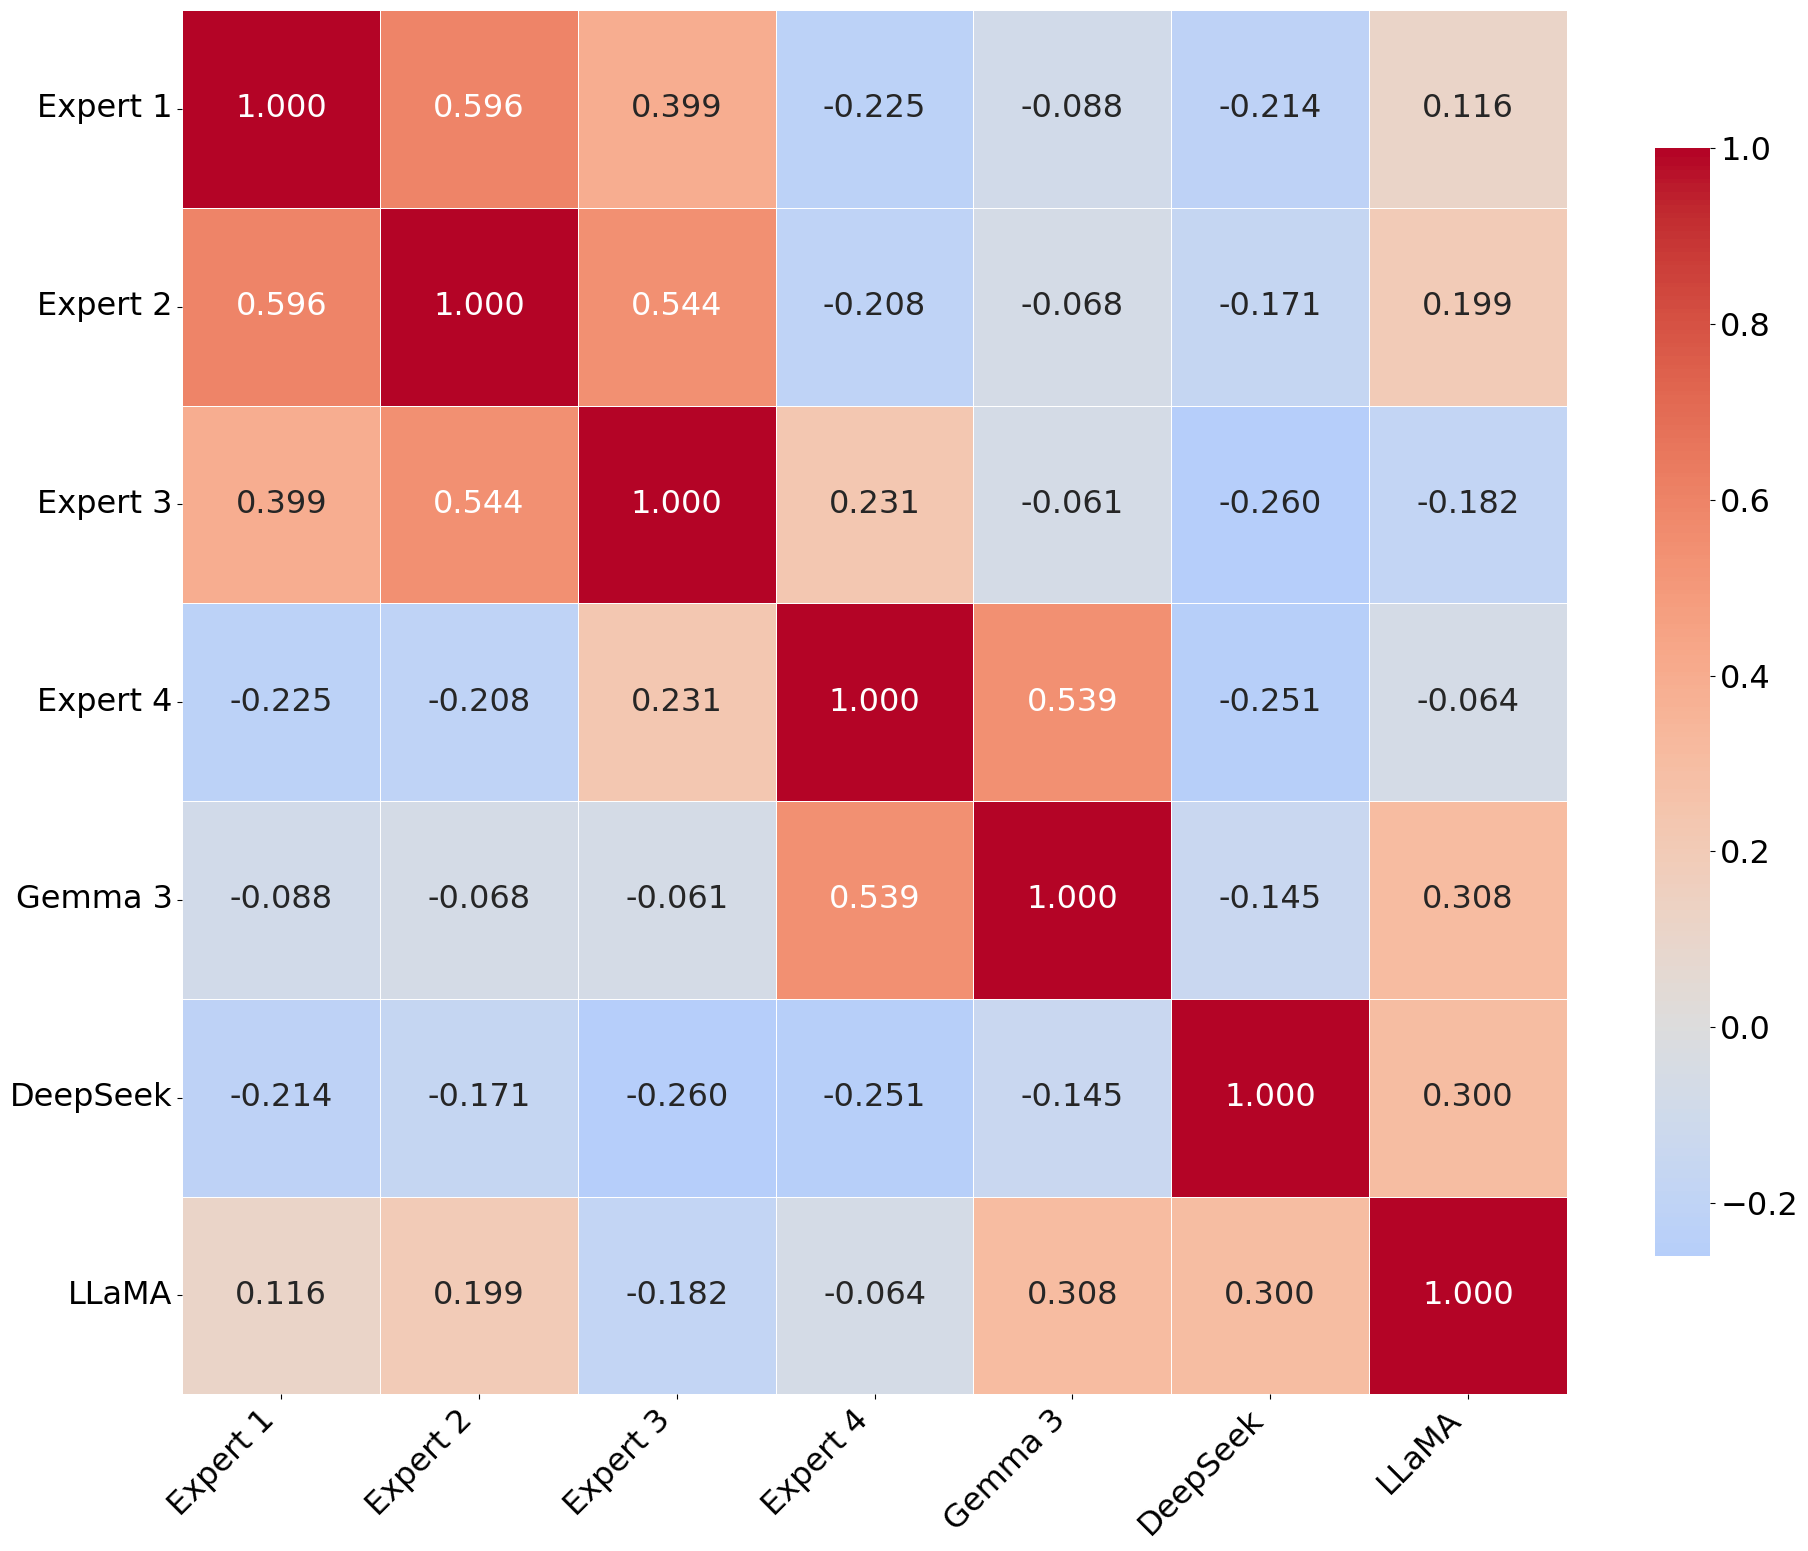

In [15]:
# Create heatmap
plt.rcParams['font.size'] = 23
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle

# Create heatmap with correlation values
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            cmap='coolwarm',  # Color scheme (red-yellow-blue reversed)
            center=0,  # Center colormap at 0
            square=True,  # Make cells square
            linewidths=0.5,  # Add grid lines
            cbar_kws={"shrink": .8},  # Adjust colorbar size
            fmt='.3f' ) # Format numbers to 3 decimal places

#plt.title('Pairwise Correlations Between Raters', fontsize=16, pad=20)
#plt.xlabel('Raters', fontsize=12)
#plt.ylabel('Raters', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('icc-correlation-heatmap2_nodirty.pdf')
plt.show()

# Create a second heatmap showing the actual ratings data

#plt.figure(figsize=(12, 8))


In [7]:
# Normalize data for better visualization (optional)
rater_data_normalized = rater_data.div(rater_data.max())

# Additional correlation statistics
print("\nDetailed Correlation Statistics:")
print("-" * 40)
# 
# Calculate pairwise correlations with p-values
try:
    from scipy.stats import pearsonr
    
    for i, rater1 in enumerate(raters):
        for j, rater2 in enumerate(raters):
            if i < j:  # Only calculate upper triangle to avoid duplicates
                corr, p_value = pearsonr(df[rater1], df[rater2])
                print(f"{rater1} vs {rater2}: r = {corr:.3f}, p = {p_value:.3f}")
                
except ImportError:
    print("scipy.stats not available, using pandas correlation only")
    print("Correlation matrix (without p-values):")
    print(correlation_matrix.round(3))

# Summary statistics for each rater
print(f"\n{'Rater':<10} {'Mean':<8} {'Std':<8} {'Min':<6} {'Max':<6}")
print("-" * 40)
for rater in raters:
    mean_val = df[rater].mean()
    std_val = df[rater].std()
    min_val = df[rater].min()
    max_val = df[rater].max()
    print(f"{rater:<10} {mean_val:<8.2f} {std_val:<8.2f} {min_val:<6} {max_val:<6}")


Detailed Correlation Statistics:
----------------------------------------
expert1 vs expert2: r = 0.596, p = 0.001
expert1 vs expert3: r = 0.399, p = 0.044
expert1 vs expert4: r = -0.225, p = 0.270
expert1 vs gemma3: r = -0.088, p = 0.670
expert1 vs deepseek: r = -0.214, p = 0.293
expert1 vs llama: r = 0.116, p = 0.571
expert2 vs expert3: r = 0.544, p = 0.004
expert2 vs expert4: r = -0.208, p = 0.308
expert2 vs gemma3: r = -0.068, p = 0.743
expert2 vs deepseek: r = -0.171, p = 0.404
expert2 vs llama: r = 0.199, p = 0.330
expert3 vs expert4: r = 0.231, p = 0.255
expert3 vs gemma3: r = -0.061, p = 0.767
expert3 vs deepseek: r = -0.260, p = 0.199
expert3 vs llama: r = -0.182, p = 0.373
expert4 vs gemma3: r = 0.539, p = 0.005
expert4 vs deepseek: r = -0.251, p = 0.215
expert4 vs llama: r = -0.064, p = 0.754
gemma3 vs deepseek: r = -0.145, p = 0.478
gemma3 vs llama: r = 0.308, p = 0.126
deepseek vs llama: r = 0.300, p = 0.137

Rater      Mean     Std      Min    Max   
--------------------

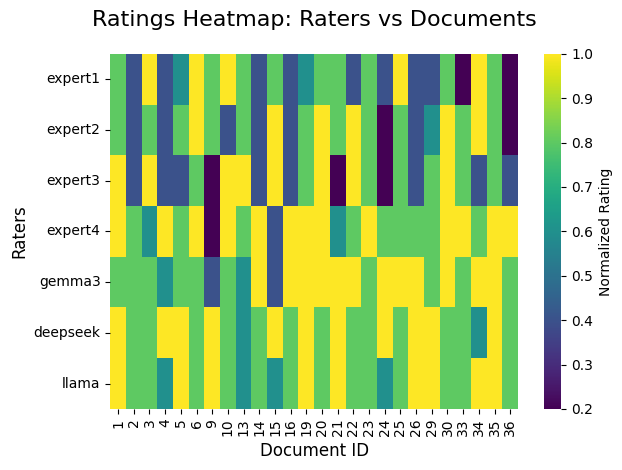

In [8]:
sns.heatmap(rater_data_normalized.T,  # Transpose so raters are on y-axis
            cmap='viridis',
            cbar_kws={'label': 'Normalized Rating'},
            xticklabels=df['document_id'].astype(str),
            yticklabels=raters)

plt.title('Ratings Heatmap: Raters vs Documents', fontsize=16, pad=20)
plt.xlabel('Document ID', fontsize=12)
plt.ylabel('Raters', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
#plt.show()